In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

plt.style.use('ggplot')

# Statistical Inference of Multiple Populations

In the previous notebook, we saw how to compare two samples. This time, we will look at the statistical methods that are used while comparing more than two groups.

##  Sequential Comparisons

The naive approach while comparing multiple groups is to use `t-tests` sequentially. For example, while comparing groups A, B, and C, we can compare (A, B), (B, C), and (A, C) one by one.

This approach has a downside. Normally, for each test, we settle for making Type 1 error rate of $\alpha$ (equivalent to $p_{critical}$). However, as the number of tests increases, the cumulative error rate (named as familywise error rate) also grows. For instance, if we select $\alpha = 0.05$, then the probability of not making a Type 1 error becomes $0.95$. For three sequential tests, this probability reduces to

$0.95^3 ≈ 0.85$

Therefore, to keep the familywise error rate (FWER) below $\alpha$, we need to make some adjustments.

### Corrective Methods for Hypothesis Testing

There are many correction methods for sequential comparisons. I will only show two of them in this notebook. For more information please refer to [this](https://en.wikipedia.org/wiki/Family-wise_error_rate) page.
   

#### Bonferroni Correction

For $m$ number of tests conducted given the dataset, $\alpha$ should be divided by $m$:

$\alpha ← \frac \alpha m$

In [2]:
alpha_critical = 0.05
alpha_new = alpha_critical/3
alpha_new

0.016666666666666666

$(1-0.0167)^3 = 0.95$

As you can see with Bonferroni Correction FWER is kept at $0.05$.

#### Šidák Correction

For $m$ number of tests conducted given the dataset, $\alpha$ should be adjusted using the formula below:

$\alpha ← 1-(1-\alpha)^{1/m}$

In [3]:
alpha_critical = 0.05
alpha_new = 1-(1-alpha_critical)**(1/3)
alpha_new

0.016952427508441503

$(1-0.0169)^3 ≈ 0.95$

### Downsides of Correction Methods

Before discussing the downsides of correction methods, let's define Type 1 and Type 2 errors.

Type 1 error is rejecting $H_0$ when $H_0$ is the case. It is often denoted by $\alpha$.

Type 2 error is not rejecting $H_0$ even when $H_1$ is the case. It is often denoted by $β$.

Power of a test refers to the probability of correctly rejecting $H_0$. It is formulated by $1-\beta$.

Type 1 and Type 2 errors are inversely correlated. As the tendency of rejecting $H_0$ increases, Type 2 error rate decreases and Type 1 error rate increases. The opposite is also true. As the test becomes more insensitive for rejecting $H_0$, its probability of making Type 1 error decreases, but this time the probability of making Type 2 error increases:

$α \uparrow β ↓$ Power $\uparrow$

$α \downarrow β \uparrow$ Power $\downarrow$


 We want our test not to suffer too much from both of these errors. Therefore, we have to carefully select parameters such as sample size and
$\alpha$. The correction methods can disturb the balance. In other words, as we make $\alpha$ smaller, the probability of a single test suffering from a Type 2 error increases.

In the next section, we will see an alternative method for multiple group comparison.




## Analysis of Variance (ANOVA)

**Note:** I will show only one-way ANOVA layout in this notebook.  

ANOVA is a statistical test used for comparing multiple groups. To conduct an ANOVA test, the following conditions have to be met:

* Samples are independent.
* Samples have similar variances.
* Samples have somewhat Gaussian distribution.

When comparing $k$ groups, we can set up the null and alternative hypotheses for ANOVA as follows:

$H_0: \mu_1 = \mu_2 = \ldots = \mu_k$

$H_1:$ At least one mean is different.

Let's see an example. We will compare 3 groups. The first step is to check requirements of ANOVA:



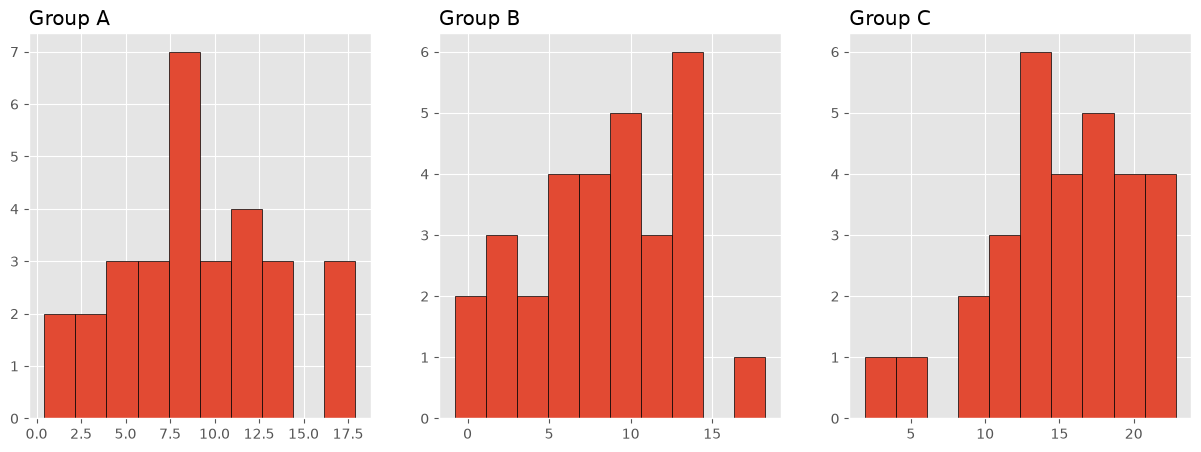

In [4]:
np.random.seed(42)
group_a = np.random.normal(loc = 10, scale = 5, size = 30)
group_b = np.random.normal(loc = 9, scale = 5, size = 30)
group_c = np.random.normal(loc = 15, scale = 5, size = 30)

fix,ax = plt.subplots(1,3,figsize = (15,5))
ax[0].hist(group_a,edgecolor = 'black')
ax[0].set_title('Group A',loc = 'left')
ax[1].hist(group_b,edgecolor = 'black')
ax[1].set_title('Group B',loc = 'left')
ax[2].hist(group_c,edgecolor = 'black')
ax[2].set_title('Group C',loc = 'left')
plt.show()


Let's analyze the variances:

In [5]:
stats.bartlett(group_a,group_b,group_c)

BartlettResult(statistic=np.float64(0.2810306157066885), pvalue=np.float64(0.8689103636785533))

The groups have *somewhat* Gaussian distribution and they have similar variances. So we can use ANOVA. The formulas we need to use for this problem:

Groups: $A,B,C$ ($k = 3$)

Sample sizes: $n_A,n_B,n_C = 30$

Sample means: $\bar{X}_A,\bar{X}_B,\bar{X}_C$

Global Mean (GB): mean of all the data points

$SS_{between} = n_A(\bar{X}_A - GB)^2 + n_B(\bar{X}_B - GB)^2 + n_C(\bar{X}_C - GB)^2$

$SS_{within} = \sum_{i = 1}^{n_A}(x_i - \bar{X}_A)^2 + \sum_{i = 1}^{n_B}(x_i - \bar{X}_B)^2 + \sum_{i = 1}^{n_C}(x_i - \bar{X}_C)^2$

$dof_{between} = k-1 = 2$

$dof_{within} = n_A + n_B + n_C - k = 87$

$MS_{between} = \frac {SS_{between}} {dof_{between}}$

$MS_{within} = \frac {SS_{within}} {dof_{within}}$

$F = \frac {MS_{between}}{MS_{within}}$

**Note:** I used open forms of the equations because closed forms can be overwhelming.



In [6]:
all_data = np.concatenate([group_a, group_b, group_c])
k = 3

n_a = len(group_a)
n_b = len(group_b)
n_c = len(group_c)

mean_a = np.mean(group_a)
mean_b = np.mean(group_b)
mean_c = np.mean(group_c)

global_mean = np.mean(all_data)

SS_between = (n_a * (mean_a - global_mean) ** 2 + \
              n_b * (mean_b - global_mean) ** 2 + \
              n_c * (mean_c - global_mean) ** 2)

SS_within = (np.sum((group_a - mean_a) ** 2) + \
             np.sum((group_b - mean_b) ** 2) + \
             np.sum((group_c - mean_c) ** 2))

df_within = len(all_data) - 3
df_between = k - 1

MS_within = SS_within / df_within
MS_between = SS_between / df_between

F_statistic = MS_between / MS_within

print(f"F-statistic: {F_statistic}")
print(f"p-value: {1-stats.f.cdf(F_statistic,df_between,df_within)}")
print(f"df_between: {df_between}")
print(f"df_within: {df_within}")
print(f"SS_between: {SS_between}")
print(f"SS_within: {SS_within}")
print(f"MS_between: {MS_between}")
print(f"MS_within: {MS_within}")

F-statistic: 18.263024265301787
p-value: 2.3855614428303085e-07
df_between: 2
df_within: 87
SS_between: 809.963064320001
SS_within: 1929.2200889674407
MS_between: 404.9815321600005
MS_within: 22.174943551349894


$p$ value of the test is smaller than $p_{critical} = 0.05$. Therefore we can conclude that the mean of at least one group is different from the rest. We will figure out which one(s) is/are different in the next section. But first, let's look at the shortcut methods for ANOVA:

In [7]:
stats.f_oneway(group_a,group_b,group_c)

F_onewayResult(statistic=np.float64(18.263024265301787), pvalue=np.float64(2.385561442783763e-07))

For a more detailed result, we can use `statsmodels` module.

In [8]:
data = {
    'values': np.concatenate([group_a, group_b, group_c]),
    'group': ['A'] * len(group_a) + ['B'] * len(group_b) + ['C'] * len(group_c)
}
df = pd.DataFrame(data)
model = ols('values ~ C(group)', data=df).fit()

anova_table = anova_lm(model)
print(anova_table)

            df       sum_sq     mean_sq          F        PR(>F)
C(group)   2.0   809.963064  404.981532  18.263024  2.385561e-07
Residual  87.0  1929.220089   22.174944        NaN           NaN


## Post-Hoc Analysis

A post-hoc analysis should be performed to understand which group(s) is/are different from the rest. There are multiple ways to do it. Personally, I have only used  `Tukey HSD` so far. It works fine and it is supported by `scipy.stats`. For the detailed explanation, you can refer to [this](https://astatsa.com/OneWay_Anova_with_TukeyHSD/) page.

In [9]:
np.random.seed(42)
group_a = np.random.normal(loc = 10, scale = 5, size = 30)
group_b = np.random.normal(loc = 9, scale = 5, size = 30)
group_c = np.random.normal(loc = 15, scale = 5, size = 30)

print(stats.tukey_hsd(group_a,group_b,group_c))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.665     0.848    -2.234     3.564
 (0 - 2)     -6.005     0.000    -8.904    -3.106
 (1 - 0)     -0.665     0.848    -3.564     2.234
 (1 - 2)     -6.670     0.000    -9.569    -3.771
 (2 - 0)      6.005     0.000     3.106     8.904
 (2 - 1)      6.670     0.000     3.771     9.569



Each row represents a pairwise comparison. We can use p-values to determine which group(s) is/are different from the others. From the results, we can conclude that the third group is different from the rest.